# Statistics for Data Science — A Practical Guide

**Goal:** Demonstrate the core statistical toolkit every data scientist needs,
applied end-to-end on a real, well-known dataset. Each technique is explained
conceptually, implemented in code, and interpreted from a **business perspective**.

**Dataset:** Titanic — 891 passengers, used here as a sandbox to illustrate
statistical reasoning rather than to build a predictive product.

---
**Contents**
1. Setup & Data Loading
2. Descriptive Statistics & the Normal Distribution
3. Z-scores & Outlier Detection
4. Correlation Analysis
5. The Binomial Distribution
6. Hypothesis Testing (t-test)
7. Confidence Intervals & A/B Testing
8. ANOVA & Post-hoc (Tukey HSD)
9. Linear Regression (statistical view)
10. Logistic Regression & Odds Ratios
11. Bootstrap
12. Bayesian Thinking
13. Conclusions

---
*Author: Cristian Cubero*


## 1. Setup & Data Loading

We load the libraries used throughout the notebook and prepare a clean version
of the dataset. Two small cleaning steps are applied up front so every later
section works on consistent data:

- **Age** has missing values — imputed with the **median** (robust to the
  right-skew we will confirm later).
- **Sex** is mapped to a binary numeric (`male = 0`, `female = 1`) so it can be
  used directly in tests and models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Minimal cleaning shared across the notebook
df['Age'] = df['Age'].fillna(df['Age'].median())   # median imputation (robust to skew)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})  # encode for tests/models

print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


## 2. Descriptive Statistics & the Normal Distribution

The **Normal (Gaussian) distribution** is the backbone of classical statistics.
It is symmetric, fully described by two parameters — the **mean (μ)** and the
**standard deviation (σ)** — and underpins t-tests, confidence intervals and
linear regression.

**The 68-95-99.7 rule.** In any normal distribution:

| Range | % of data |
|-------|-----------|
| μ ± 1σ | 68% |
| μ ± 2σ | 95% |
| μ ± 3σ | 99.7% |

A value more than 3σ away from the mean is extremely rare. We visualize the age
distribution against its mean and ±1σ band.


Mean: 29.4   |   Std: 13.0


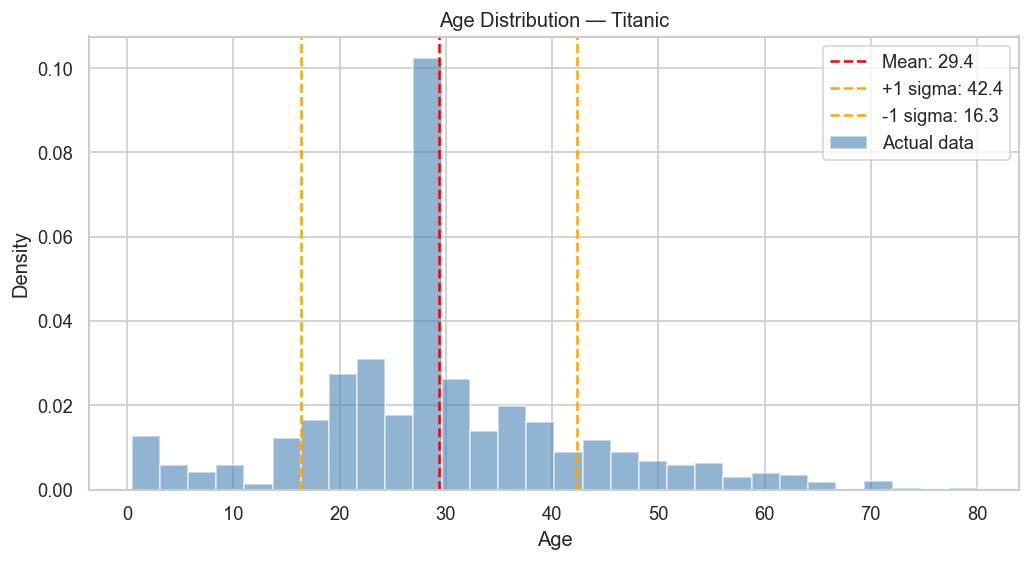

In [2]:
ages = df['Age']
mean, std = ages.mean(), ages.std()
print(f'Mean: {mean:.1f}   |   Std: {std:.1f}')

plt.figure(figsize=(10, 5))
plt.hist(ages, bins=30, density=True, alpha=0.6, color='steelblue', label='Actual data')
plt.axvline(mean,        color='red',    linestyle='--', label=f'Mean: {mean:.1f}')
plt.axvline(mean + std,  color='orange', linestyle='--', label=f'+1 sigma: {mean+std:.1f}')
plt.axvline(mean - std,  color='orange', linestyle='--', label=f'-1 sigma: {mean-std:.1f}')
plt.title('Age Distribution — Titanic')
plt.xlabel('Age'); plt.ylabel('Density'); plt.legend()
plt.show()

The distribution is roughly bell-shaped but shows a **slight right skew**
(more young passengers than old). It is close enough to normal to reason about,
but the skew is a useful early signal — it will matter again when we compare the
mean vs. the median of fares in the Bootstrap section.


## 3. Z-scores & Outlier Detection

A **Z-score** expresses how many standard deviations a value sits from the mean:

$$ Z = \frac{x - \mu}{\sigma} $$

- `Z = 0` → exactly at the mean
- `Z = +2` → two standard deviations above
- `|Z| > 3` → a common rule-of-thumb threshold for outliers

Z-scores also let us **compare variables measured on different scales**, and they
are the conceptual basis of hypothesis testing.


In [3]:
df['Age_z'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()

outliers = df[df['Age_z'].abs() > 3]
print(f'Passengers flagged as age outliers (|Z| > 3): {len(outliers)}')
outliers[['Name', 'Age', 'Age_z']].sort_values('Age', ascending=False)

Passengers flagged as age outliers (|Z| > 3): 7


,Name,Age,Age_z
630,"Barkworth, Mr. Algernon Henry Wilson",80.0,3.889370
851,"Svensson, Mr. Johan",74.0,3.428530
96,"Goldschmidt, Mr. George B",71.0,3.198110
493,"Artagaveytia, Mr. Ramon",71.0,3.198110
116,"Connors, Mr. Patrick",70.5,3.159706
672,"Mitchell, Mr. Henry Michael",70.0,3.121303
745,"Crosby, Capt. Edward Gifford",70.0,3.121303


These are the oldest passengers on board — genuinely unusual ages rather
than data errors. **Caveat:** the Z-score method assumes approximate normality,
so for strongly skewed variables the IQR method is usually preferred.


## 4. Correlation Analysis

**Correlation** measures the linear relationship between two variables, ranging
from -1 to +1:

| Value | Meaning |
|-------|---------|
| +1 | perfect positive |
| 0  | no linear relationship |
| -1 | perfect negative |

It is a fast way to spot which variables move together — useful both for finding
predictive signal and for detecting **multicollinearity** (predictors that
overlap with each other).


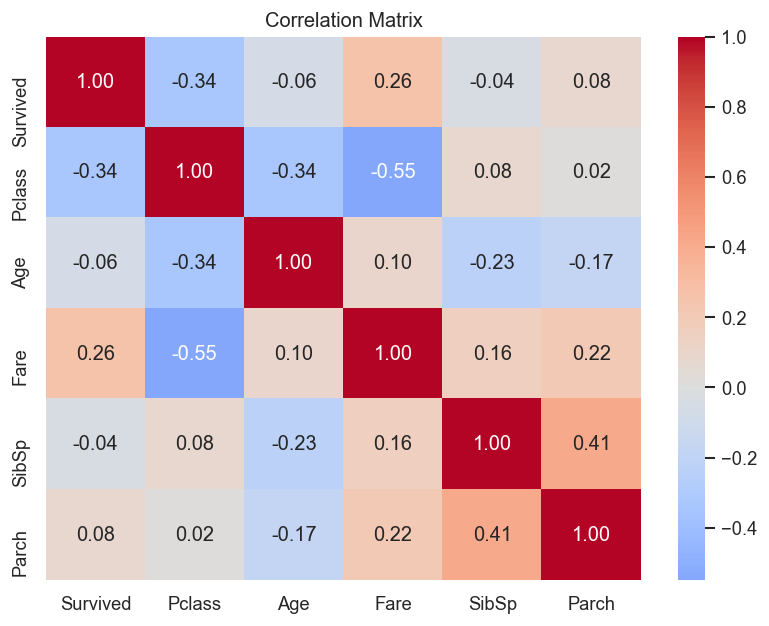

In [4]:
corr = df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

**Reading the matrix:**

- `Pclass` has the strongest correlation with `Survived` (negative — class 1 is a
  low number but a high survival rate).
- `Fare` is positively correlated with `Survived`: passengers who paid more
  tended to survive more.
- `Pclass` and `Fare` correlate with **each other** (~0.55) — first-class tickets
  cost more. This is multicollinearity: not a problem for tree models, but it
  matters for linear regression interpretation.


## 5. The Binomial Distribution

The **Binomial** models the number of successes in *n* independent trials, each
with success probability *p*:

$$ P(X = k) = \binom{n}{k}\, p^{k} (1-p)^{n-k} $$

It is the foundation of **logistic regression** and of most **A/B testing**.
Here we ask: if we draw 10 random passengers, how many do we expect to survive,
given the overall survival rate?


Survival probability p = 38.38%


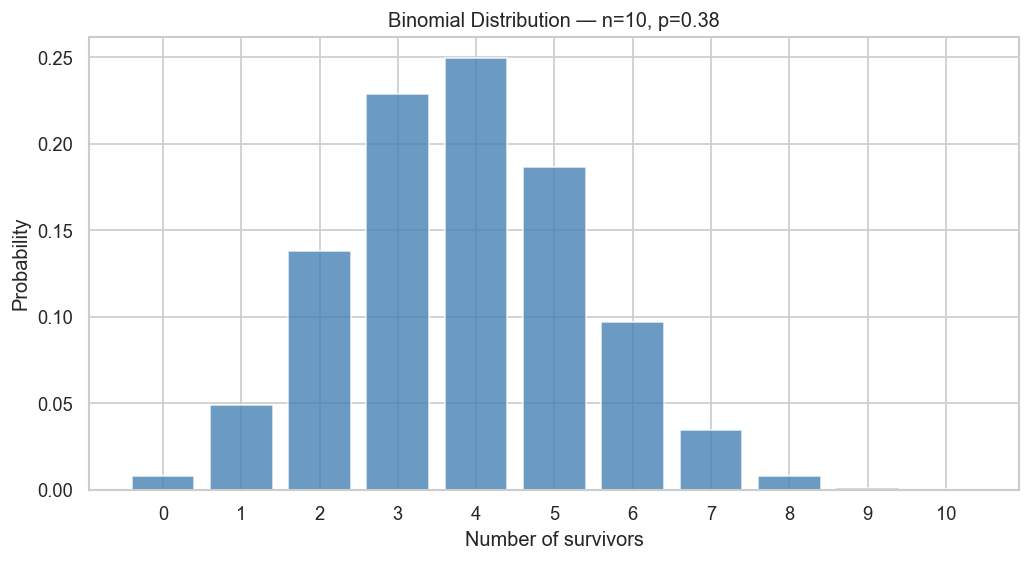

P(exactly 3 survive) : 22.88%
P(at least 5 survive): 32.70%


In [5]:
p = df['Survived'].mean()   # overall survival probability
n = 10
print(f'Survival probability p = {p:.2%}')

x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, p)

plt.figure(figsize=(10, 5))
plt.bar(x, pmf, color='steelblue', alpha=0.8)
plt.xticks(x)
plt.title(f'Binomial Distribution — n={n}, p={p:.2f}')
plt.xlabel('Number of survivors'); plt.ylabel('Probability')
plt.show()

print(f'P(exactly 3 survive) : {stats.binom.pmf(3, n, p):.2%}')
print(f'P(at least 5 survive): {1 - stats.binom.cdf(4, n, p):.2%}')

The distribution peaks at 3–4 survivors, exactly where we'd expect with
`p ≈ 0.38`. Note the probability rules:

- **Exactly N** → `pmf(N)`
- **At most N** → `cdf(N)`
- **At least N** → `1 - cdf(N-1)`


## 6. Hypothesis Testing (t-test)

Hypothesis testing turns a question into a statistical decision:

- **H₀ (null):** there is no difference / no effect.
- **H₁ (alternative):** there is a difference / an effect.

The **p-value** is the probability of observing our result *if H₀ were true*.
By convention, `p < 0.05` → reject H₀ → the result is **statistically
significant**.

The **t-statistic** scales the difference between groups by its variability:

$$ t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}} $$

**Question:** did women really survive more than men, or could it be chance?


In [6]:
women = df[df['Sex'] == 1]['Survived']
men   = df[df['Sex'] == 0]['Survived']

t_stat, p_value = stats.ttest_ind(women, men)
print(f'Women survival rate: {women.mean():.2%}')
print(f'Men survival rate  : {men.mean():.2%}')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value    : {p_value:.6e}')
print('Reject H0 — difference is statistically significant'
      if p_value < 0.05 else 'Fail to reject H0')

Women survival rate: 74.20%
Men survival rate  : 18.89%

T-statistic: 19.2978
P-value    : 1.406066e-69
Reject H0 — difference is statistically significant


The p-value is effectively zero and the t-statistic is very large (~19):
the survival gap between women and men is **not** due to chance. The larger the
`|t|`, the smaller the p-value, the stronger the evidence.


## 7. Confidence Intervals & A/B Testing

An **A/B test** compares two versions of something (a price, an email, a layout)
to decide which performs better — the everyday workhorse of data-driven decisions.

A **confidence interval (CI)** quantifies the uncertainty of an estimate. A 95%
CI means: *"with 95% confidence, the true value lies within this range."*

$$ CI = \bar{x} \pm t^{*} \cdot SEM, \qquad SEM = \frac{\sigma}{\sqrt{n}} $$

**Decision rule:** if the CIs of the two groups **don't overlap**, the difference
is significant. Here we treat ticket class as the "A/B" groups and compare fares.


In [7]:
class1 = df[df['Pclass'] == 1]['Fare']
class2 = df[df['Pclass'] == 2]['Fare']

t_stat, p_value = stats.ttest_ind(class1, class2)
print(f'Class 1 mean fare: ${class1.mean():.2f}')
print(f'Class 2 mean fare: ${class2.mean():.2f}')
print(f'P-value: {p_value:.6e}')

ci1 = stats.t.interval(0.95, len(class1)-1, loc=class1.mean(), scale=stats.sem(class1))
ci2 = stats.t.interval(0.95, len(class2)-1, loc=class2.mean(), scale=stats.sem(class2))
print(f'\nClass 1 95% CI: (${ci1[0]:.2f}, ${ci1[1]:.2f})')
print(f'Class 2 95% CI: (${ci2[0]:.2f}, ${ci2[1]:.2f})')

Class 1 mean fare: $84.15
Class 2 mean fare: $20.66
P-value: 3.303644e-24

Class 1 95% CI: ($73.64, $94.67)
Class 2 95% CI: ($18.71, $22.61)


The intervals are far apart and do not overlap, confirming a real price
difference between first and second class. The CI also communicates **precision**:
a wide interval signals more uncertainty (smaller sample or higher variance).


## 8. ANOVA & Post-hoc (Tukey HSD)

When comparing **more than two groups**, running many t-tests inflates the chance
of a false positive. **ANOVA** tests a single question instead:

- **H₀:** all group means are equal.
- **H₁:** at least one group differs.

ANOVA tells us *that* something differs, but not *which* pair. The **Tukey HSD**
post-hoc test fills that gap by comparing every pair while controlling the error
rate. We test whether average fare differs across the three passenger classes.


In [8]:
c1 = df[df['Pclass'] == 1]['Fare']
c2 = df[df['Pclass'] == 2]['Fare']
c3 = df[df['Pclass'] == 3]['Fare']

f_stat, p_value = stats.f_oneway(c1, c2, c3)
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value    : {p_value:.6e}')
print('Reject H0 — at least one class differs'
      if p_value < 0.05 else 'Fail to reject H0')

F-statistic: 242.3442
P-value    : 1.031376e-84
Reject H0 — at least one class differs


In [9]:
tukey = pairwise_tukeyhsd(df['Fare'], df['Pclass'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2 -63.4925  0.001 -72.9167 -54.0683   True
     1      3 -70.4791  0.001 -78.1491 -62.8092   True
     2      3  -6.9866 0.1081 -15.1066   1.1333  False
------------------------------------------------------


**Interpretation:**

- Class 1 vs 2 and Class 1 vs 3 → `reject = True`: first class is clearly
  more expensive.
- Class 2 vs 3 → `reject = False`: the ~\$7 gap is **not** significant; second
  and third class are statistically similar in price.

So the price premium is concentrated in first class — a sharper conclusion than
ANOVA alone could give.


## 9. Linear Regression (statistical view)

`scikit-learn` gives predictions; `statsmodels` gives **inference** — it tells us
*which variables matter and how much*. The model is:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \varepsilon $$

We model `Fare` as a function of `Pclass` and `Age`, then read the summary.


In [10]:
model = smf.ols('Fare ~ Pclass + Age', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Fare   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     200.5
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           1.36e-72
Time:                        16:12:40   Log-Likelihood:                -4577.9
No. Observations:                 891   AIC:                             9162.
Df Residuals:                     888   BIC:                             9176.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    123.7704      6.214     19.918      0.0

**What to read first:**

- **R-squared** — the share of variance explained (here the model captures only
  part of fare variation; class and age alone don't tell the whole story).
- **coef** — effect of each variable. A negative `Pclass` coefficient means fare
  drops as class number rises (1 → 2 → 3), which matches reality.
- **P>|t|** — significance of each predictor. Below 0.05 → the variable carries
  real signal; above 0.05 → consider dropping it.

The key interpretation phrase: *"holding everything else constant, a one-unit
increase in X changes Y by [coef]."* Saying "holding everything else constant"
shows you understand what a coefficient actually measures.


## 10. Logistic Regression & Odds Ratios

For **classification** (yes/no outcomes), linear regression fails because it can
predict values outside [0, 1]. Logistic regression applies the **sigmoid** to
squash any input into a valid probability:

$$ P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots)}} $$

The raw coefficients are hard to read. Exponentiating them gives **odds ratios**,
which translate directly into business language:

- **OR > 1** → increases the odds of the outcome
- **OR < 1** → decreases the odds
- **OR = 1** → no effect


In [11]:
logit = smf.logit('Survived ~ Sex + Pclass + Age', data=df).fit()
print(logit.summary())

print('\n--- Odds Ratios ---')
print(np.exp(logit.params).round(3))

Optimization terminated successfully.
         Current function value: 0.452069
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      887
Method:                           MLE   Df Model:                            3
Date:                Thu, 18 Jun 2026   Pseudo R-squ.:                  0.3211
Time:                        16:12:40   Log-Likelihood:                -402.79
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 2.792e-82
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1125      0.406      5.203      0.000       1.317       2.908
Sex            2.6123      0.

**Interpretation in plain language:**

- **Sex (OR ≈ 13.6):** women had roughly **13x** higher odds of survival than
  men, controlling for class and age.
- **Pclass (OR ≈ 0.31):** each step down in class cuts the odds to ~31% of the
  previous level.
- **Age (OR ≈ 0.97):** each additional year slightly lowers survival odds (~3%).

Note the **Pseudo R-squared** (~0.32): it is **not** read like ordinary R².
On the McFadden scale, values of **0.2–0.4 already indicate a good fit**. The
business takeaway — *"women were ~13x more likely to survive than men"* — is the
kind of translation from coefficient to insight that stakeholders actually use.


### Visualizing the Model

Coefficients and odds ratios describe the model numerically; plotting the
**predicted probability curves** makes it intuitive. Each curve is the sigmoid the
model uses to turn the inputs into a probability between 0 and 1. We vary `Age`
along the x-axis while holding the other variables fixed, so each line isolates
the effect of one factor.

- **Left — effect of Sex:** with class held constant, the female curve sits far
  above the male curve at every age. This is the odds ratio of ~13.6 made visual.
- **Right — effect of Class:** for women, first class stays highest and third
  class lowest, mirroring the ~0.31 odds ratio per step down in class.
- **Downward slope:** every curve declines with age, reflecting the ~0.97 odds
  ratio per additional year.
- **The 50% line** is the default decision threshold — above it the model predicts
  "survived", below it "did not".

Explaining a classifier visually like this is often the most effective way to
communicate it to a non-technical audience.

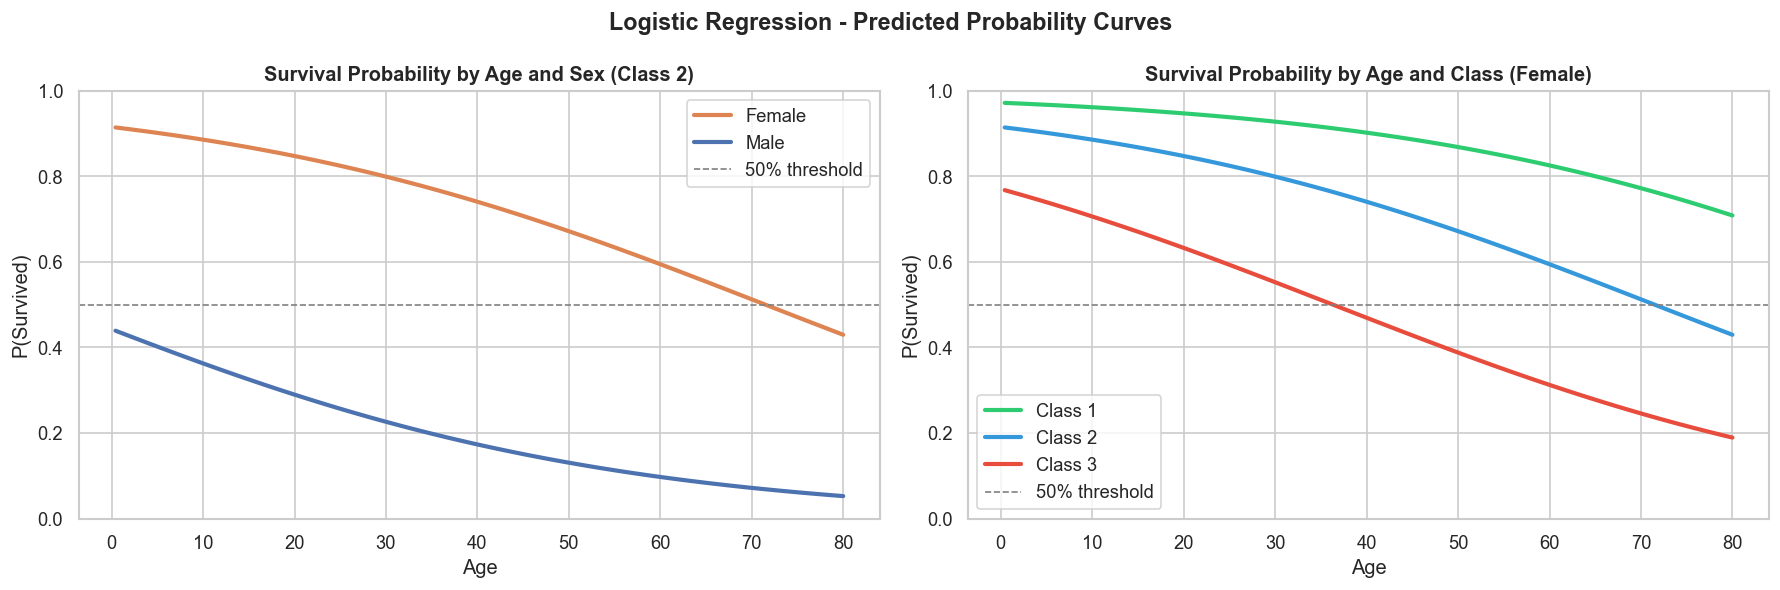

In [12]:
# Predicted survival probability curves across Age, by Sex and Class
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: effect of Sex (holding Pclass = 2)
for sex_val, label, color in [(1, 'Female', '#DD8452'), (0, 'Male', '#4C72B0')]:
    scenario = pd.DataFrame({'Age': age_range, 'Sex': sex_val, 'Pclass': 2})
    probs = logit.predict(scenario)
    axes[0].plot(age_range, probs, color=color, linewidth=2.5, label=label)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% threshold')
axes[0].set_title('Survival Probability by Age and Sex (Class 2)', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('P(Survived)')
axes[0].set_ylim(0, 1); axes[0].legend()

# Right plot: effect of Class (holding Sex = female)
colors = ['#2ecc71', '#3498db', '#e74c3c']
for pclass_val, color in zip([1, 2, 3], colors):
    scenario = pd.DataFrame({'Age': age_range, 'Sex': 1, 'Pclass': pclass_val})
    probs = logit.predict(scenario)
    axes[1].plot(age_range, probs, color=color, linewidth=2.5, label=f'Class {pclass_val}')

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% threshold')
axes[1].set_title('Survival Probability by Age and Class (Female)', fontweight='bold')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('P(Survived)')
axes[1].set_ylim(0, 1); axes[1].legend()

plt.suptitle('Logistic Regression - Predicted Probability Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Bootstrap

The **bootstrap** estimates the uncertainty of *any* statistic by resampling the
data itself — no distributional assumptions required.

The procedure:
1. Resample the data **with replacement** (same size as the original).
2. Compute the statistic of interest.
3. Repeat thousands of times.
4. Read the 2.5th and 97.5th percentiles for a 95% CI.

Its real power: it works for statistics that have **no simple formula** (median,
percentiles, correlations) and it handles **skewed data** honestly. We apply it
to both the mean and the median of `Fare`.


In [13]:
np.random.seed(42)
fares = df['Fare'].dropna().values

def bootstrap_ci(data, stat_fn, n_iter=10000):
    """Return the 95% bootstrap confidence interval for a given statistic."""
    estimates = [stat_fn(np.random.choice(data, size=len(data), replace=True))
                 for _ in range(n_iter)]
    return np.percentile(estimates, [2.5, 97.5])

mean_ci   = bootstrap_ci(fares, np.mean)
median_ci = bootstrap_ci(fares, np.median)

print(f'Mean   fare: ${fares.mean():.2f}   95% CI: (${mean_ci[0]:.2f}, ${mean_ci[1]:.2f})')
print(f'Median fare: ${np.median(fares):.2f}   95% CI: (${median_ci[0]:.2f}, ${median_ci[1]:.2f})')

Mean   fare: $32.20   95% CI: ($29.12, $35.53)
Median fare: $14.45   95% CI: ($13.00, $15.55)


The mean fare (~\$32) is **more than double** the median (~\$14). That gap is
the fingerprint of a **right-skewed** distribution: a few wealthy first-class
passengers pull the mean up, while most passengers paid around \$14.

**Business takeaway — which to report:**

```
When to use each:
- Skewed data (prices, income, response times) -> median
- Symmetric data (heights, errors)             -> mean
```

Telling a manager *"the typical passenger paid ~$14; the mean rises to $32
because of a few premium fares"* is far more honest than quoting the mean alone.


## 12. Bayesian Thinking

Bayesian reasoning is about **updating beliefs when new information arrives**.

**Conditional probability** `P(A | B)` reads as *"the probability of A given that
B happened."* Crucially, `P(A|B)` and `P(B|A)` are **different questions** —
swapping them is a classic error (the *confusion of the inverse*).

**Bayes' theorem** lets us flip one into the other:

$$ P(A|B) = \frac{P(B|A)\,P(A)}{P(B)} $$

| Term | Role |
|------|------|
| `P(A)` | **prior** — belief before evidence |
| `P(B\|A)` | **likelihood** |
| `P(B)` | **evidence** (normalizer) |
| `P(A\|B)` | **posterior** — updated belief |

**Question:** given that a passenger survived, how likely is it that they were a
woman?


In [14]:
p_woman             = (df['Sex'] == 1).mean()                 # prior
p_survived          = df['Survived'].mean()                    # evidence
p_survived_if_woman = df[df['Sex'] == 1]['Survived'].mean()    # likelihood

# Bayes' theorem
p_woman_if_survived = (p_survived_if_woman * p_woman) / p_survived

print(f'Prior      P(woman)              : {p_woman:.2%}')
print(f'Likelihood P(survived | woman)   : {p_survived_if_woman:.2%}')
print(f'Evidence   P(survived)           : {p_survived:.2%}')
print(f'Posterior  P(woman | survived)   : {p_woman_if_survived:.2%}')

# Sanity check: counting directly must match Bayes
direct = df[df['Survived'] == 1]['Sex'].mean()
print(f'\nDirect count P(woman | survived): {direct:.2%}  (matches Bayes)')

Prior      P(woman)              : 35.24%
Likelihood P(survived | woman)   : 74.20%
Evidence   P(survived)           : 38.38%
Posterior  P(woman | survived)   : 68.13%

Direct count P(woman | survived): 68.13%  (matches Bayes)


The **prior** (a random passenger is ~35% likely to be a woman) updates to a
**posterior** of ~68% once we learn the passenger survived. The evidence nearly
**doubled** our belief, because survival was a strong signal of being a woman.

This is exactly how a **Naive Bayes** classifier reasons — start from a prior and
adjust with each piece of evidence. Bayes is indispensable when you can't count
directly and only have the separate probabilities to combine (spam filters,
medical testing, A/B analysis).


## 13. Conclusions

This notebook walked through the statistical toolkit a data scientist relies on
daily, each technique tied to a concrete question and a business interpretation:

| Technique | What it answers |
|-----------|-----------------|
| Distributions & Z-scores | Is this value typical or extreme? |
| Correlation | Which variables move together? |
| Binomial | How likely are *k* successes in *n* trials? |
| t-test | Is the difference between two groups real? |
| Confidence intervals | How precise is my estimate? |
| ANOVA + Tukey | Which of several groups differ? |
| Linear regression | How much does each driver affect a number? |
| Logistic regression | Which factors drive a yes/no outcome, and by how much? |
| Bootstrap | How uncertain is *any* statistic, assumption-free? |
| Bayesian thinking | How should evidence update my beliefs? |

**The recurring theme:** the math is only half the job — translating each result
into a clear, decision-ready statement for a non-technical audience is what turns
analysis into impact.
